In [1]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import datetime as dt

import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [2]:
import sys

sys.path.append("../src")
sys.path.append("../src/bout")

In [3]:
from core import SITE_NAMES, FREQ_GROUPS
import clustering as clstr
import bout.assembly as bt
import bout.clustering as clstr
import plot as bt_plt
import activity.subsampling as ss
import activity.activity_assembly as actvt
import pipeline

from cli import get_file_paths

In [4]:
site_key = 'Telephone'
freq_key = 'HF'

bout_params = dict()
bout_params['site_key'] = site_key
bout_params['freq_key'] = freq_key

fig_details = dict()
fig_details['site_name'] = SITE_NAMES[site_key]
fig_details['freq_group'] = freq_key.split('_')[0].upper()
if freq_key:
    fig_details['freq_group'] = fig_details['freq_group'] + ' '
fig_details['bin_step'] = 10
fig_details['time_end'] = 1000
print(f'Looking at {fig_details["site_name"]}')
HF_location_df = pd.read_csv(f'../data/2022_detector_summaries/{bout_params["site_key"]}/bd2__{bout_params["freq_key"]}{bout_params["site_key"]}_2022_kmeans.csv', index_col=0, dtype='object')

Looking at Telephone Field


Telephone HF Min: 35520.0
Telephone HF Max: 83520.0
Telephone HF Median: 46080.0
Telephone HF Mean: 47326.77795625797


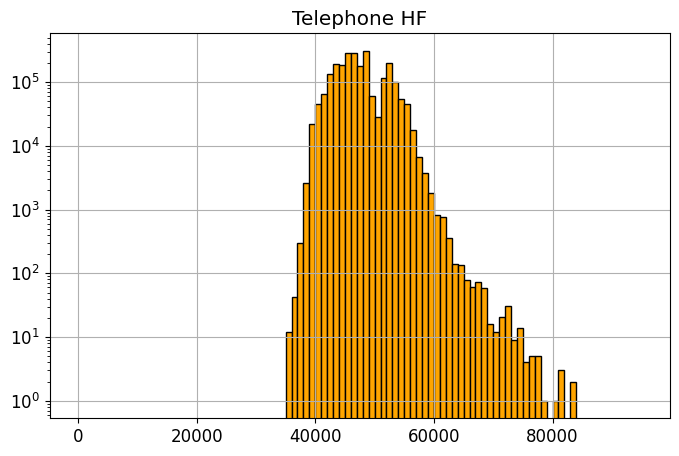

In [5]:
stat_arr = HF_location_df.peak_frequency_WELCH.astype(float)
print(f"{site_key} {freq_key} Min: {stat_arr.min()}")
print(f"{site_key} {freq_key} Max: {stat_arr.max()}")
print(f"{site_key} {freq_key} Median: {stat_arr.median()}")
print(f"{site_key} {freq_key} Mean: {stat_arr.mean()}")

plt.figure(figsize=(8,5))
plt.rcParams.update({'font.size':12})
plt.title(f'{site_key} {freq_key}')
plt.hist(stat_arr, bins=np.arange(0, 96000, 1000), facecolor='orange', edgecolor='k')
plt.yscale('log')
plt.grid(which='major')
plt.show()

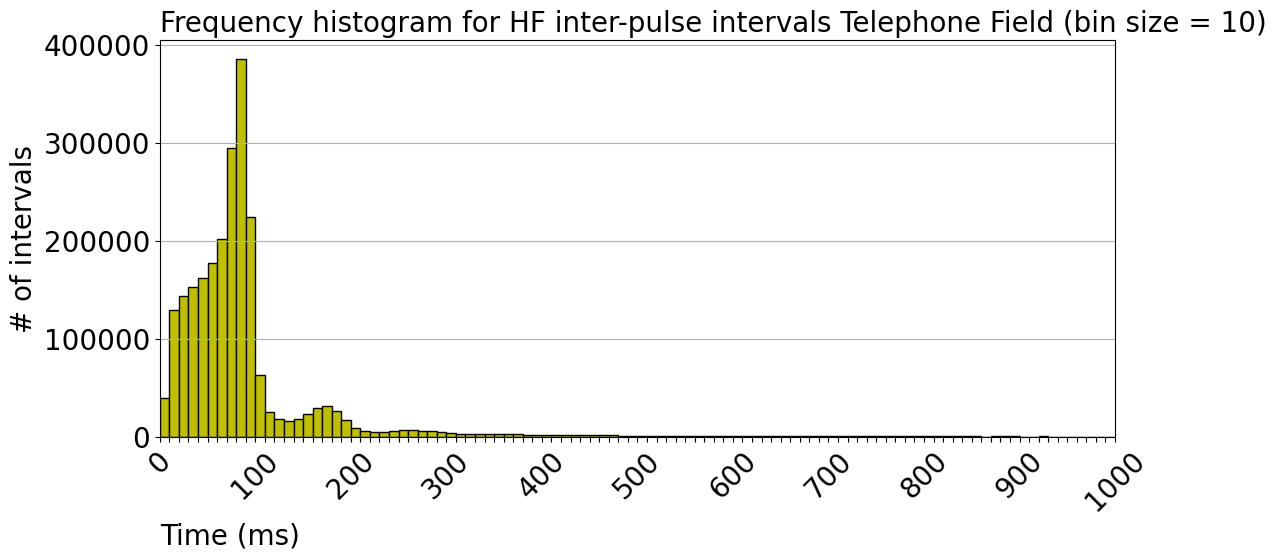

In [6]:
ipis_f, hist_f = bt_plt.plot_ipi_hist(HF_location_df.copy(), fig_details)

In [7]:
freq_key = 'LF'

bout_params = dict()
bout_params['site_key'] = site_key
bout_params['freq_key'] = freq_key

fig_details = dict()
fig_details['site_name'] = SITE_NAMES[site_key]
fig_details['freq_group'] = freq_key.split('_')[0].upper()
if freq_key:
    fig_details['freq_group'] = fig_details['freq_group'] + ' '
fig_details['bin_step'] = 10
fig_details['time_end'] = 1000
print(f'Looking at {fig_details["site_name"]}')
LF_location_df = pd.read_csv(f'../data/2022_detector_summaries/{bout_params["site_key"]}/bd2__{bout_params["freq_key"]}{bout_params["site_key"]}_2022_kmeans.csv', index_col=0, dtype='object')

Looking at Telephone Field


Telephone LF Min: 13440.000000000002
Telephone LF Max: 40320.0
Telephone LF Median: 26880.000000000004
Telephone LF Mean: 27089.553102118574


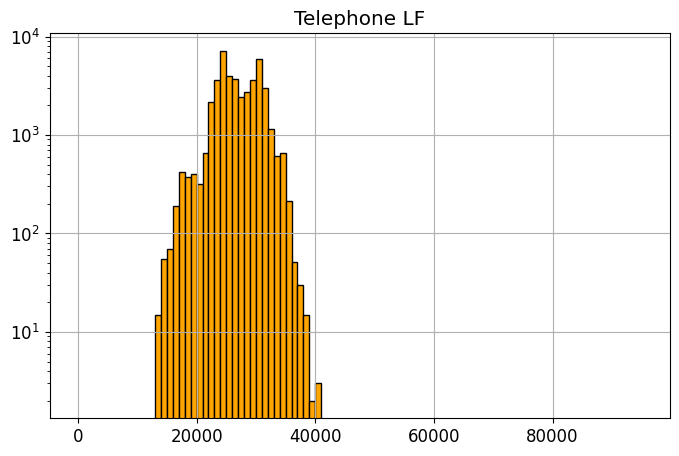

In [8]:
stat_arr = LF_location_df.peak_frequency_WELCH.astype(float)
print(f"{site_key} {freq_key} Min: {stat_arr.min()}")
print(f"{site_key} {freq_key} Max: {stat_arr.max()}")
print(f"{site_key} {freq_key} Median: {stat_arr.median()}")
print(f"{site_key} {freq_key} Mean: {stat_arr.mean()}")

plt.figure(figsize=(8,5))
plt.rcParams.update({'font.size':12})
plt.title(f'{site_key} {freq_key}')
plt.hist(stat_arr, bins=np.arange(0, 96000, 1000), facecolor='orange', edgecolor='k')
plt.yscale('log')
plt.grid(which='major')
plt.show()

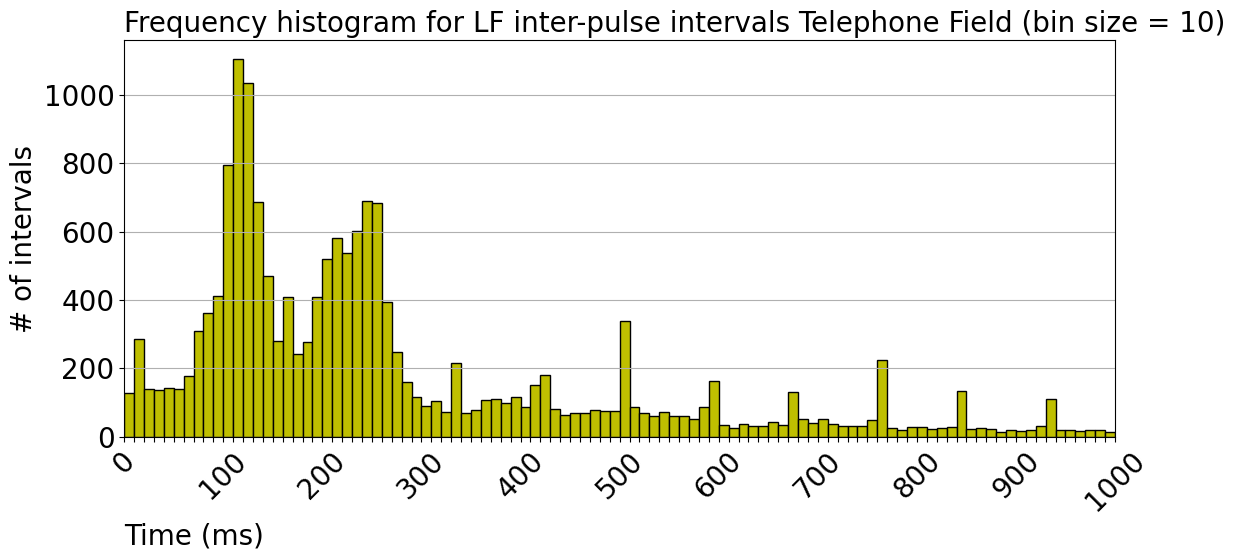

In [9]:
ipis_f, hist_f = bt_plt.plot_ipi_hist(LF_location_df.copy(), fig_details)

Telephone LF Min: 13440.000000000002
Telephone LF Max: 40320.0
Telephone LF Median: 26880.000000000004
Telephone LF Mean: 27089.553102118574
Telephone HF Min: 35520.0
Telephone HF Max: 83520.0
Telephone HF Median: 46080.0
Telephone HF Mean: 47326.77795625797


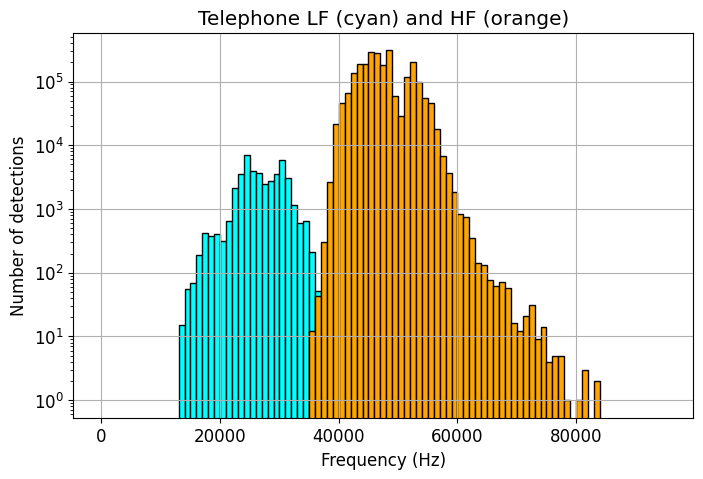

In [10]:
freq_key = "LF"
stat_arr = LF_location_df.peak_frequency_WELCH.astype(float)
print(f"{site_key} {freq_key} Min: {stat_arr.min()}")
print(f"{site_key} {freq_key} Max: {stat_arr.max()}")
print(f"{site_key} {freq_key} Median: {stat_arr.median()}")
print(f"{site_key} {freq_key} Mean: {stat_arr.mean()}")

plt.figure(figsize=(8,5))
plt.rcParams.update({'font.size':12})
plt.title(f'{site_key} LF (cyan) and HF (orange)')
plt.hist(stat_arr, bins=np.arange(0, 96000, 1000), facecolor='cyan', edgecolor='k')
plt.yscale('log')
plt.grid(which='major')

freq_key = 'HF'
stat_arr = HF_location_df.peak_frequency_WELCH.astype(float)
print(f"{site_key} {freq_key} Min: {stat_arr.min()}")
print(f"{site_key} {freq_key} Max: {stat_arr.max()}")
print(f"{site_key} {freq_key} Median: {stat_arr.median()}")
print(f"{site_key} {freq_key} Mean: {stat_arr.mean()}")

plt.hist(stat_arr, bins=np.arange(0, 96000, 1000), facecolor='orange', edgecolor='k')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Number of detections')
plt.show()